<a href="https://colab.research.google.com/github/09-ashish/ICT_Exit_Test/blob/main/pokemon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [229]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


TASK 1

In [230]:
df=pd.read_csv("/content/G2.csv")

In [231]:
data.head()

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense
0,1,bulbasaur,7,69,64.0,grass,poison,45,49,49
1,2,ivysaur,10,130,142.0,grass,poison,60,62,63
2,3,venusaur,20,1000,236.0,grass,poison,80,82,83
3,4,charmander,6,85,62.0,fire,NaN,39,52,43
4,5,charmeleon,11,190,142.0,fire,NaN,58,64,58


In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1351 non-null   int64  
 1   name             1351 non-null   object 
 2   height_dm        1351 non-null   int64  
 3   weight_hg        1351 non-null   int64  
 4   base_experience  1302 non-null   float64
 5   type_1           1351 non-null   object 
 6   type_2           765 non-null    object 
 7   hp               1351 non-null   int64  
 8   attack           1351 non-null   int64  
 9   defense          1351 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 105.7+ KB


In [233]:
df.shape


(1351, 10)

In [234]:
df.describe()

,id,height_dm,weight_hg,base_experience,hp,attack,defense
count,1351.000000,1351.000000,1351.000000,1302.000000,1351.000000,1351.000000,1351.000000
mean,2841.692080,20.443375,991.059956,161.943932,71.673575,82.757957,76.193930
std,4139.019112,53.238467,1953.115812,82.532554,26.827529,32.351906,30.712902
min,1.000000,1.000000,0.000000,36.000000,1.000000,5.000000,5.000000
25%,338.500000,6.000000,94.500000,71.000000,55.000000,60.000000,55.000000
50%,676.000000,11.000000,326.000000,165.000000,70.000000,80.000000,70.000000
75%,1013.500000,17.000000,853.500000,222.500000,85.000000,102.500000,95.000000
max,10326.000000,1000.000000,10000.000000,608.000000,255.000000,190.000000,250.000000


In [235]:
df.isnull().sum()

,0
id,0
name,0
height_dm,0
weight_hg,0
base_experience,49
type_1,0
type_2,586
hp,0
attack,0
defense,0


In [236]:
df.duplicated().sum()

np.int64(0)

In [237]:
type_counts = df['type_1'].value_counts()

print(type_counts)


type_1
water       160
normal      139
grass       122
electric    100
bug          95
psychic      86
fire         84
rock         83
dark         63
fighting     62
dragon       59
steel        52
poison       52
ghost        52
ground       50
ice          44
fairy        35
flying       13
Name: count, dtype: int64


**Analytics:**
1. Water type pokemon appears the most frequently in the dataset.
2. the weight shows the greatest variation among pokemon because it has a standard deviation greater than the rest features.
3. the dataset has 1351 observations. there are no duplicated items but base_experience and type_2 has null values.


TASK 2

In [238]:
df['base_experience'].fillna(df['base_experience'].median(), inplace=True)

/tmp/ipykernel_1819/711206339.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['base_experience'].fillna(df['base_experience'].median(), inplace=True)


In [239]:
df['type_2']=df['type_2'].fillna('None')

In [240]:

label= LabelEncoder()
df['type_1_encoded'] = label.fit_transform(df['type_1'])

In [241]:
df = pd.get_dummies(df,columns=['type_2'],drop_first=False)

In [242]:
X = df[['height_dm','weight_hg','base_experience','hp','attack','defense',]]

y = df['type_1_encoded']

In [243]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

**Analytics**
1. preprocessing helps us to understand whether there are missing or duplicated values in our dataset and treat them so that the ml model can learn pattern easily.
2. I replaced the missing values with "None" because the we dont knwo whether the pokemon has a second type or not , so we cannot fill it with mode.

TASK 3

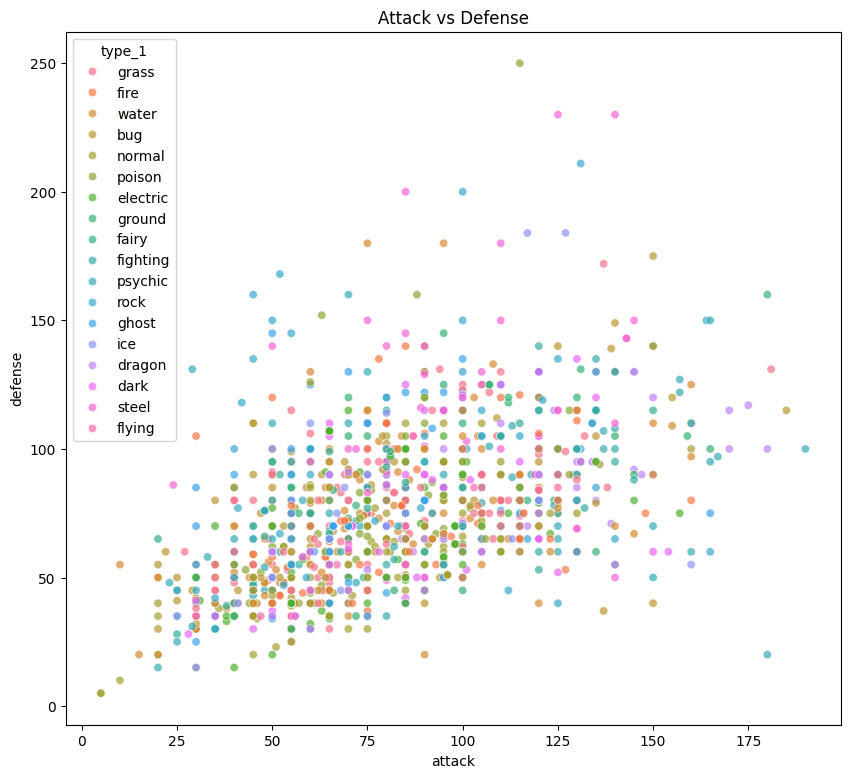

In [244]:
plt.figure(figsize=(10,9))
sns.scatterplot(
    data=df,
    x='attack',
    y='defense',
    hue='type_1',
    alpha=0.7
)

plt.title("Attack vs Defense")

plt.show()

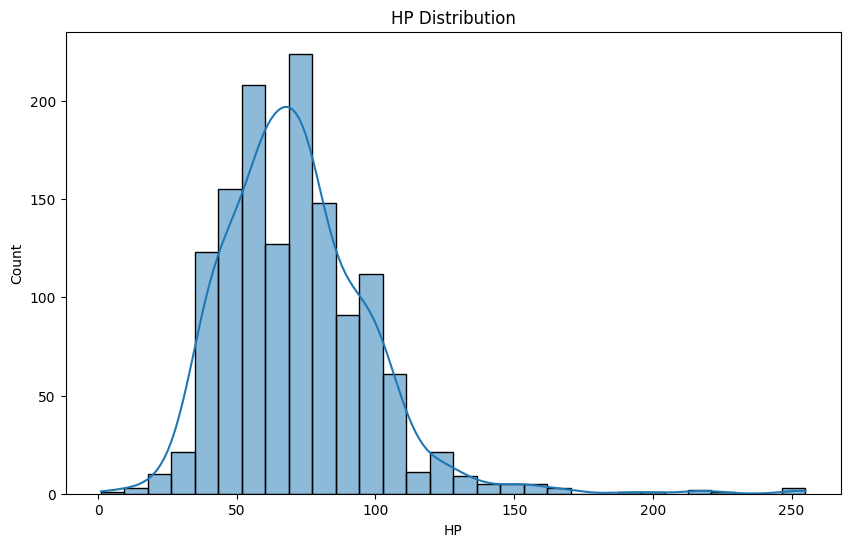

In [245]:
plt.figure(figsize=(10,6))
sns.histplot(df['hp'], bins=30, kde=True)

plt.title("HP Distribution")
plt.xlabel("HP")
plt.show()

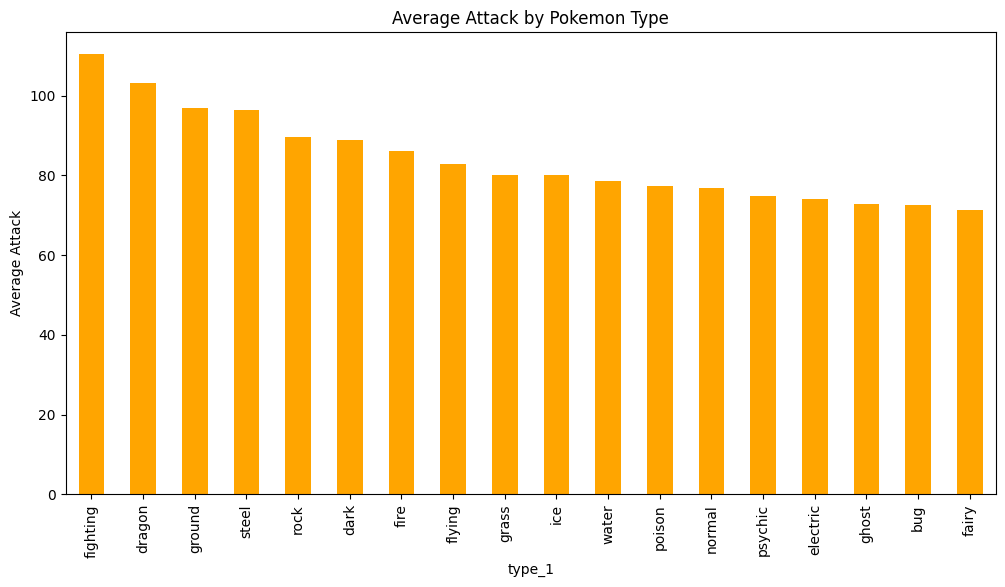

In [246]:
attack_by_type = df.groupby('type_1')['attack'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
attack_by_type.plot(kind='bar', color='orange')
plt.title('Average Attack by Pokemon Type')
plt.ylabel('Average Attack')
plt.show()

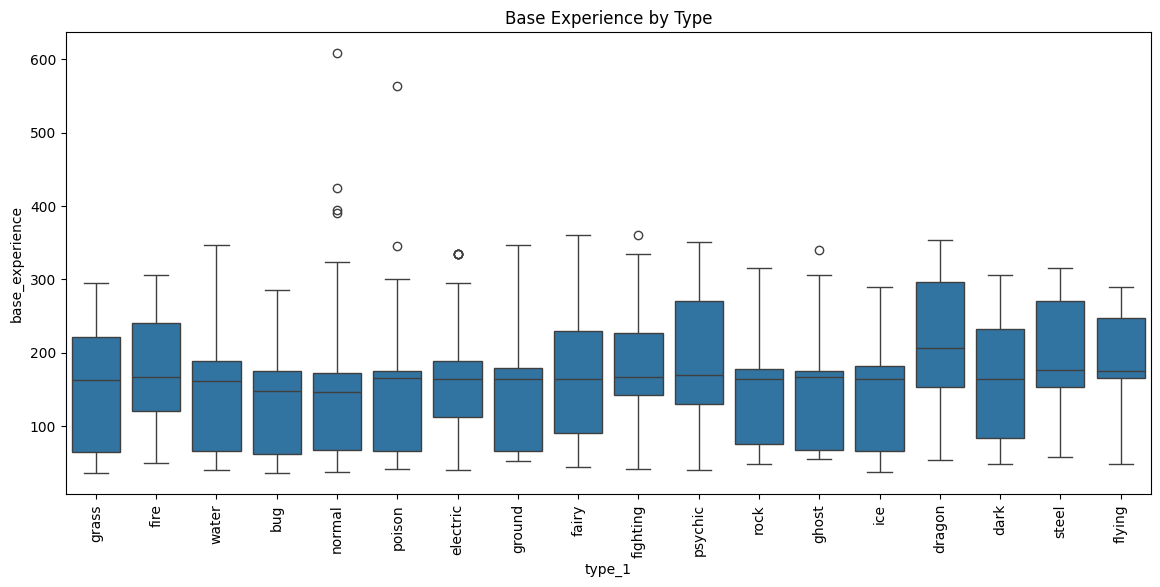

In [247]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x='type_1',
    y='base_experience'
)

plt.xticks(rotation=90)
plt.title("Base Experience by Type")
plt.show()

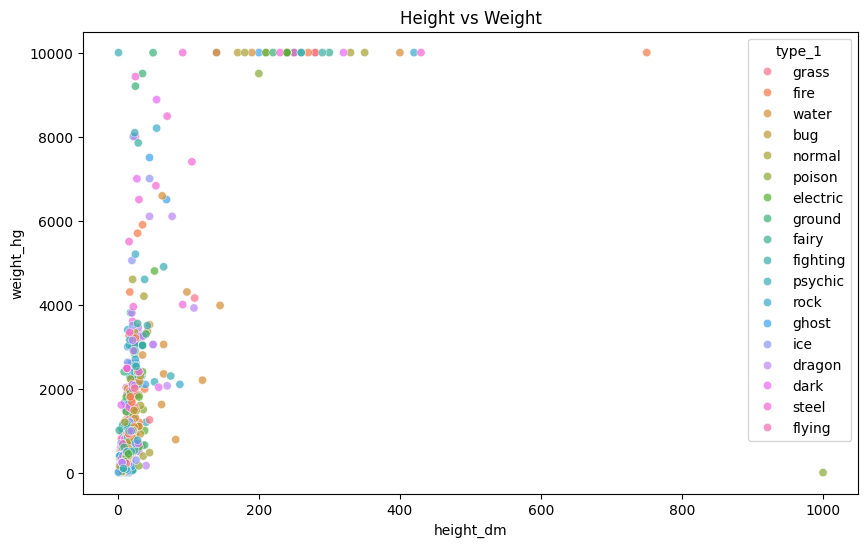

In [248]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='height_dm',
    y='weight_hg',
    hue='type_1',
    alpha=0.7
)

plt.title("Height vs Weight")
plt.show()

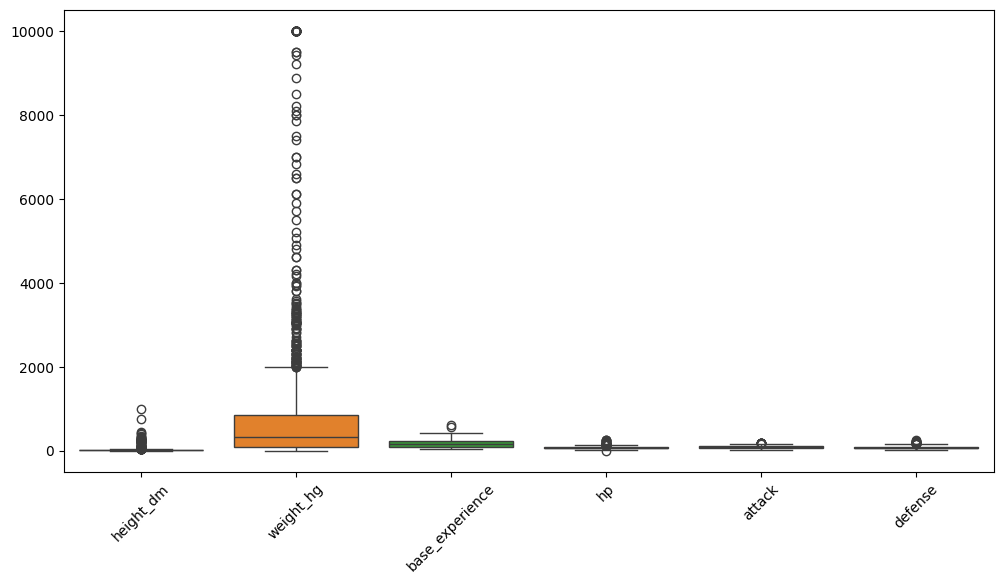

In [249]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[['height_dm',
                     'weight_hg',
                     'base_experience',
                     'hp',
                     'attack',
                     'defense']])

plt.xticks(rotation=45)
plt.show()

In [250]:
corr = df['height_dm'].corr(df['weight_hg'])

print("Correlation =", corr)

Correlation = 0.6716213754423365


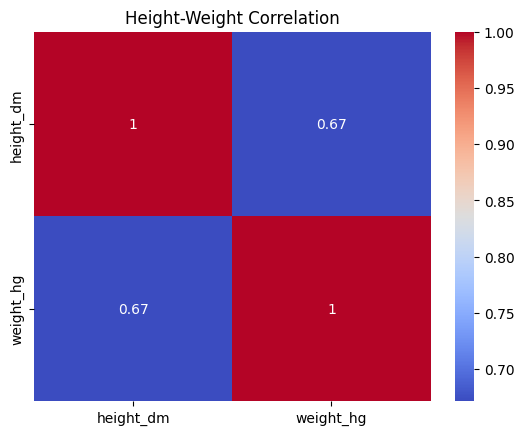

In [251]:
sns.heatmap(
    df[['height_dm','weight_hg']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Height-Weight Correlation')
plt.show()

**Analytics**

1. fighting type pokemon has highest average attack.
2. yes , as the height of the pokemon increases the weight also tends to increase.but there some exceptions where tall pokemons are lighter and some short pokemons are heavier.
3. the attack and defence appear most useful for distinuguising pokemons types.

TASK 4

In [252]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report as cr, accuracy_score, precision_score, recall_score, f1_score,ConfusionMatrixDisplay as cm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

In [253]:
for col in ['height_dm',
            'weight_hg',
            'base_experience',
            'hp',
            'attack',
            'defense']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [254]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [255]:
#logistic regression
lr = LogisticRegression(
    max_iter=10000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [256]:
print(accuracy_score(y_test, lr_pred))

0.16974169741697417


In [257]:
#decision tre
dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [258]:
#random classifier
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [259]:
#gradient boosting
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)


In [270]:
from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

print(results.sort_values(
    by="Accuracy",
    ascending=False
))

                 Model  Accuracy
2        Random Forest  0.287823
3    Gradient Boosting  0.258303
1        Decision Tree  0.188192
0  Logistic Regression  0.169742


In [261]:
print(cr(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.31      0.42      0.36        19
           1       0.29      0.15      0.20        13
           2       0.36      0.33      0.35        12
           3       0.53      0.40      0.46        20
           4       0.00      0.00      0.00         7
           5       0.20      0.17      0.18        12
           6       0.22      0.24      0.23        17
           7       0.00      0.00      0.00         3
           8       0.40      0.20      0.27        10
           9       0.25      0.24      0.24        25
          10       0.40      0.20      0.27        10
          11       0.00      0.00      0.00         9
          12       0.36      0.46      0.41        28
          13       0.25      0.20      0.22        10
          14       0.33      0.35      0.34        17
          15       0.44      0.47      0.46        17
          16       0.27      0.30      0.29        10
          17       0.16    

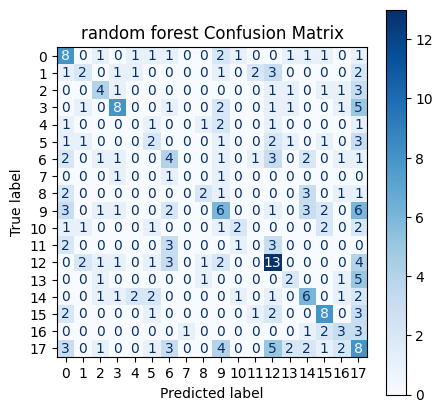

In [262]:
fig, ax = plt.subplots(figsize=(5, 5))
cm.from_estimator(rf, X_test, y_test, cmap='Blues', ax=ax)
plt.title("random forest Confusion Matrix")
plt.show()

In [263]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': rf_pred
})

errors = comparison[
    comparison['Actual'] != comparison['Predicted']
]

misclassified = errors.groupby(
    ['Actual','Predicted']
).size().reset_index(name='Count')

misclassified = misclassified.sort_values(
    by='Count',
    ascending=False
)

print(misclassified.head(15))

     Actual  Predicted  Count
67        9         17      6
89       13         17      5
112      17         12      5
29        3         17      5
111      17          9      4
85       12         17      4
57        8         14      3
82       12          6      3
75       11          6      3
106      16         17      3
102      15         17      3
110      17          6      3
107      17          0      3
42        5         17      3
65        9         14      3


In [264]:
rf.feature_importances_

array([0.13749167, 0.19006109, 0.18852354, 0.15647045, 0.1659632 ,
       0.16149005])

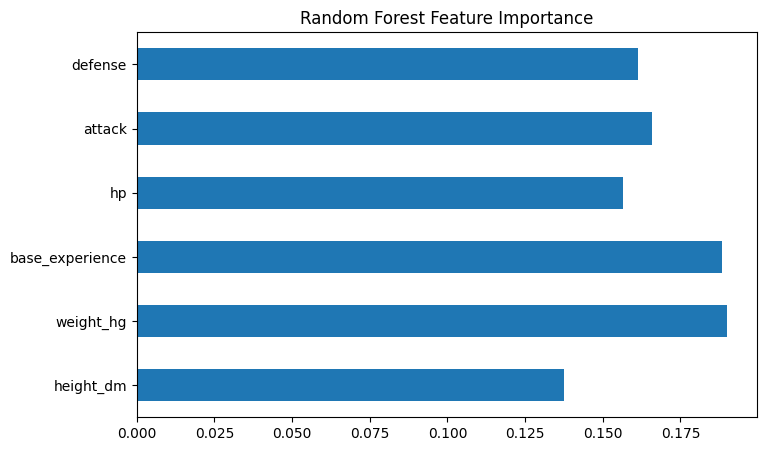

In [265]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

importance.plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Random Forest Feature Importance")
plt.show()

**Analytics**
1. random forest achieved best performancew as it has the highest accuracy of 29%.
2. normal,grass rock ,psychic types were most frequently misclassified.
3. water and normal pokemon have similar hp and defenxe , rock and ground have higher defence.

TASK 5

In [266]:
import pickle
pickle.dump(
    scaler,
    open('scaler.pkl', 'wb')

)
pickle.dump(
    rf,
    open('pokemon_model.pkl','wb')
)

pickle.dump(
    label,
    open('label_encoder.pkl','wb')
)

**Analytics**
1. The application can assist the game developes or players by predicting the type of pokemon based on the physical and combat statistics so that the players can choose the rival pokemon type which is stronger over the current type.

2. the limitation is that the predictions are not very accurate as it predicted from only 6 input features but the correct pokemon type is  included in models top3 predictions.

In [267]:
import os

print(os.path.exists('pokemon_model.pkl'))

True


In [271]:
from google.colab import files

files.download('pokemon_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [272]:
df.head()

,id,name,height_dm,weight_hg,base_experience,type_1,hp,attack,defense,type_1_encoded,...,type_2_ghost,type_2_grass,type_2_ground,type_2_ice,type_2_normal,type_2_poison,type_2_psychic,type_2_rock,type_2_steel,type_2_water
0,1,bulbasaur,7.0,69,64.0,grass,45,49.0,49,9,...,False,False,False,False,False,True,False,False,False,False
1,2,ivysaur,10.0,130,142.0,grass,60,62.0,63,9,...,False,False,False,False,False,True,False,False,False,False
2,3,venusaur,20.0,1000,236.0,grass,80,82.0,83,9,...,False,False,False,False,False,True,False,False,False,False
3,4,charmander,6.0,85,62.0,fire,39,52.0,43,6,...,False,False,False,False,False,False,False,False,False,False
4,5,charmeleon,11.0,190,142.0,fire,58,64.0,58,6,...,False,False,False,False,False,False,False,False,False,False
